# 기계학습과 인공신경망 10장: RNN 실습

본 내용은 아래 참고 링크에서 가져온 것이며 더 자세한 설명은 아래 링크에서 확인 가능.

참고 링크: https://datascienceschool.net/view-notebook/1d93b9dc6c624fbaa6af2ce9290e2479/


## 학습 목표
- 시계열 데이터를 RNN 입력 형태 `(samples, timesteps, features)`로 변환한다.
- sequence-to-point와 sequence-to-sequence 예측의 차이를 이해한다.
- SimpleRNN의 학습 전/후 예측 결과를 시각화한다.

## 사용할 데이터
- `load_data('time-series')`: 예제 시계열 데이터

## 직접 바꿔볼 것
- 입력 sequence 길이 `p`
- RNN neuron 수
- epoch 수


In [2]:
# !pip install anndata
# !pip install mlbi-lab --upgrade

In [3]:
from __future__ import absolute_import, division, print_function, unicode_literals
import tensorflow as tf

from tensorflow.keras.layers import Dense, Flatten, Conv2D
from tensorflow.keras import Model

In [4]:
import math, os
import numpy as np
import pandas as pd
import sklearn.linear_model as lm
import sklearn.model_selection as mod_sel
import sklearn.metrics as met
from numpy.random import randn
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz

from mlbi.datasets import load_data, load_anndata

/mnt/HDD2/Google_drive/PyPI_Git_Publish/pub_mlbi_lab/src/mlbi/datasets.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# 0. 사용할 데이터 생성

(1) 실험 파라미터 설정 및 sequence 데이터 생성

In [5]:
load_data()

You can select one of:
  cancerseek
  ccle-ctrpv2
  heart_failure
  hotel_bookings
  house_price
  labor_force
  metabric
  scores
  tcga-brca
  time-series
  time-series2


In [6]:
df = load_data('time-series')

In [7]:
df

,TS1,TS2
0,3.343,3.365
1,3.566,3.714
2,3.985,4.243
3,4.383,4.522
4,4.524,4.327
...,...,...
1495,3.763,3.776
1496,4.009,3.800
1497,4.365,3.844
1498,4.603,4.129


In [8]:
t = df.index.values

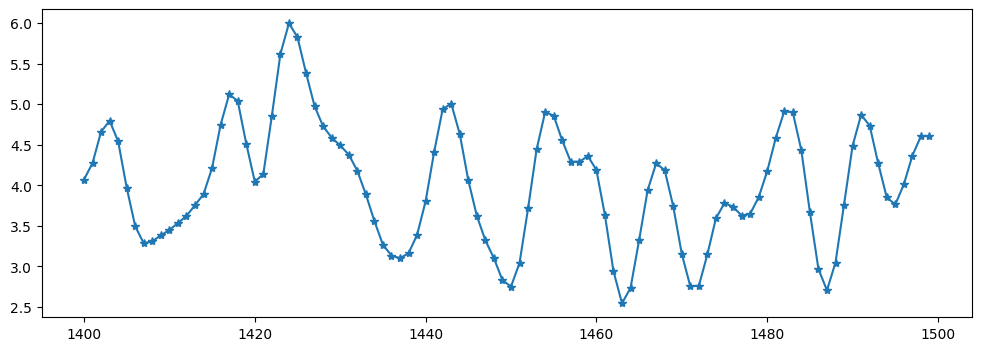

In [9]:
## 사용할 Time series 의 선택 및 Perturbation 추가
target = 'TS1'
perturbation = 0.01
N_to_plot = 100

t = df.index.values
s = np.array(df[target])
s = s + randn(len(s))*(s.std()*perturbation)

plt.figure(figsize = (12,4))
plt.plot(t[-N_to_plot:], s[-N_to_plot:], '*-')
plt.show()

(2) Sequence를 다루려면 Toeplitz 행렬형으로 바꿔야 ...

In [10]:
# 예측 차수
p = 10
q = 1

c = np.flip(s[:(p+q)])
r = s[(p+q-1):]
S = np.fliplr(toeplitz(r, c))

In [11]:
s[:13].round(2)

array([3.33, 3.57, 3.98, 4.39, 4.52, 4.33, 4.  , 3.86, 4.04, 4.41, 4.52,
       4.29, 3.89])

In [12]:
X = S[:,:p][:, :, np.newaxis]
y = S[:,p:(p+q)]

test_size = 0.25
N_samples = X.shape[0]
N_timesteps = p
N_targets = q

N_train = int(N_samples*(1-test_size))
N_test = int(N_samples*test_size)

y_test = y[-N_test:]
X_test = X[-N_test:,:,:]

y_train = y[:N_train]
X_train = X[:N_train,:,:]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1117, 10, 1), (1117, 1), (372, 10, 1), (372, 1))

In [13]:
S

array([[3.33396966, 3.57086369, 3.9772853 , ..., 4.04418749, 4.40595528,
        4.52336267],
       [3.57086369, 3.9772853 , 4.38652485, ..., 4.40595528, 4.52336267,
        4.28812971],
       [3.9772853 , 4.38652485, 4.52265513, ..., 4.52336267, 4.28812971,
        3.88911608],
       ...,
       [2.7041821 , 3.04678824, 3.7625178 , ..., 3.76294722, 4.01048671,
        4.36587407],
       [3.04678824, 3.7625178 , 4.48757095, ..., 4.01048671, 4.36587407,
        4.60522567],
       [3.7625178 , 4.48757095, 4.86958576, ..., 4.36587407, 4.60522567,
        4.60683985]])

# 1. Sequence prediction - (Seq-to-point)

(1) 학습 데이터와 목표값 설정

In [14]:
N_samples, N_train, N_test, N_timesteps

(1490, 1117, 372, 10)

In [15]:
X_train.shape, y_train.shape

((1117, 10, 1), (1117, 1))

(2) 학습 데이터와 목표 값 확인

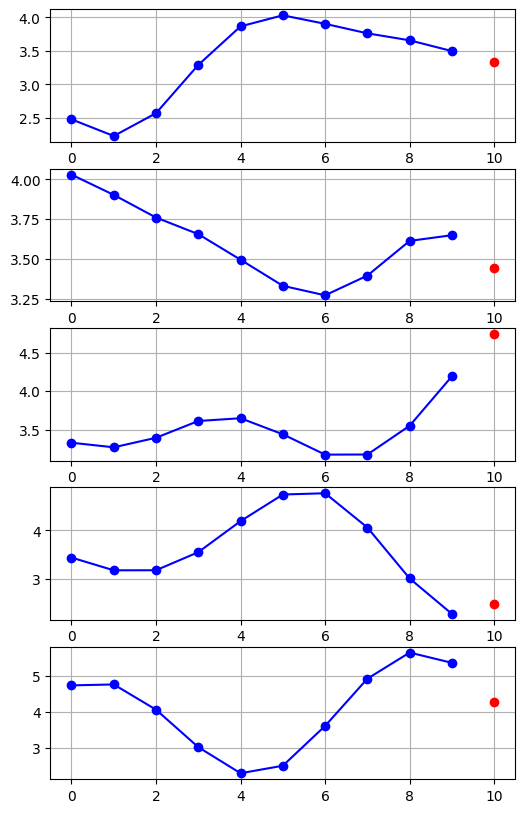

In [16]:
Nplt = 5
step = 5
plt.figure(figsize = (6, 2*Nplt))
for i in range(Nplt):
    plt.subplot(Nplt,1,i+1)
    plt.plot(np.arange(p), X_test[i*step,:], 'bo-', label="input seq")
    plt.plot(np.arange(q)+p, y_test[i*step], 'ro-', label="target")
    # plt.legend()
    plt.grid()
plt.show()

(3) 모델 생성

#### 회귀 신경망 (RNN) 모형

<div style="display:flex; gap:24px; align-items:flex-start;">
  <img src="data:image/png;base64, ..." width="700"/>  
</div>


<div style="display:flex; gap:24px; align-items:flex-start;">
  <img src="data:image/png;base64, ..." width="700"/>  
</div>


In [17]:
N_timesteps ## p

10

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

N_RNN_neurons = 10

np.random.seed(0)
model = Sequential()
model.add(SimpleRNN(N_RNN_neurons, input_shape=(N_timesteps, 1)))
model.add(Dense(N_targets, activation="linear"))
model.compile(loss='mse', optimizer='sgd',
              metrics=['mse'])

model.summary()

E0000 00:00:1782035204.840689 2048427 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1782035204.841262 2049059 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1782035204.887950 2048427 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/syoon/Programs/anaconda3/envs/py312/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a la

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

(4) 학습 전 출력 확인

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


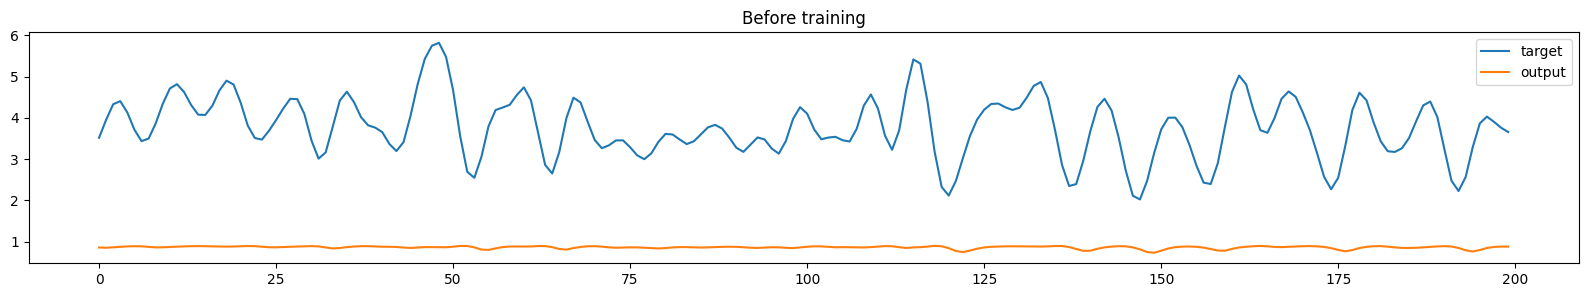

In [19]:
y_pred = model.predict(X_train)

plt.figure(figsize = (20,3))
plt.plot(y_train[-200:,:], label="target")
plt.plot(y_pred[-200:,:], label="output")
plt.legend()
plt.title("Before training")
plt.show()

(5) 모델 훈련 (학습) 및 손실함수 확인

In [20]:
X_train.shape, y_train.shape

((1117, 10, 1), (1117, 1))

In [21]:
print('Training .. ', end='')
history = model.fit(X_train, y_train, epochs=50, verbose=1)
print('done')

Training .. Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0368 - mse: 1.0368 
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3718 - mse: 0.3718
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2981 - mse: 0.2981
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2476 - mse: 0.2476
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2114 - mse: 0.2114
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1819 - mse: 0.1819
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1582 - mse: 0.1582
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1388 - mse: 0.1388
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1261 - mse: 0.1261
Epoch 10/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1122 - mse: 0.1122
Epoch 11/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1033 - mse: 0.1033
Epoch 12/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0973 - mse: 0.0973
Epoch 13/50
35/35 ━━━━━━━━━━━━━━━━━━

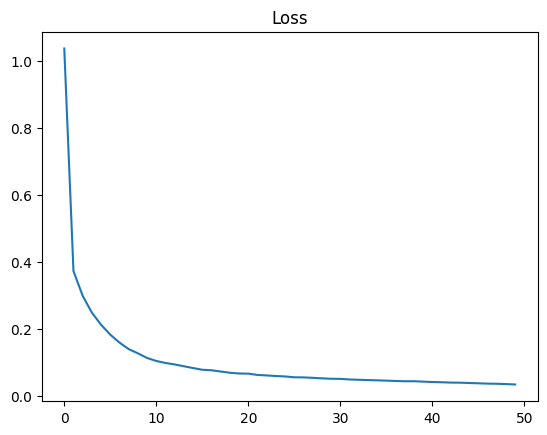

In [22]:
plt.plot(history.history["loss"])
plt.title("Loss")
plt.show()

(6) 학습 후 출력 확인

In [23]:
y_pred = model.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [24]:
y_pred

array([[3.4294312],
       [3.3123267],
       [3.407181 ],
       [3.6240907],
       [3.8349183],
       [3.6457324],
       [3.2688596],
       [3.1138012],
       [3.4123085],
       [4.013275 ],
       [4.6032085],
       [4.8532963],
       [4.4598827],
       [3.3265166],
       [2.2227817],
       [2.108718 ],
       [3.2413106],
       [4.6913376],
       [5.3531685],
       [5.469511 ],
       [4.740733 ],
       [3.2414849],
       [2.3351269],
       [2.6646602],
       [3.3642764],
       [4.008685 ],
       [3.960361 ],
       [3.569974 ],
       [3.4626117],
       [3.876644 ],
       [4.481931 ],
       [4.788663 ],
       [4.6725297],
       [4.2714076],
       [3.7264755],
       [3.374535 ],
       [3.2083375],
       [3.1159463],
       [3.066237 ],
       [3.1638746],
       [3.1536052],
       [3.2881913],
       [3.6987593],
       [4.1583705],
       [4.5455856],
       [4.512234 ],
       [4.0398655],
       [3.334779 ],
       [3.0075302],
       [3.2525332],


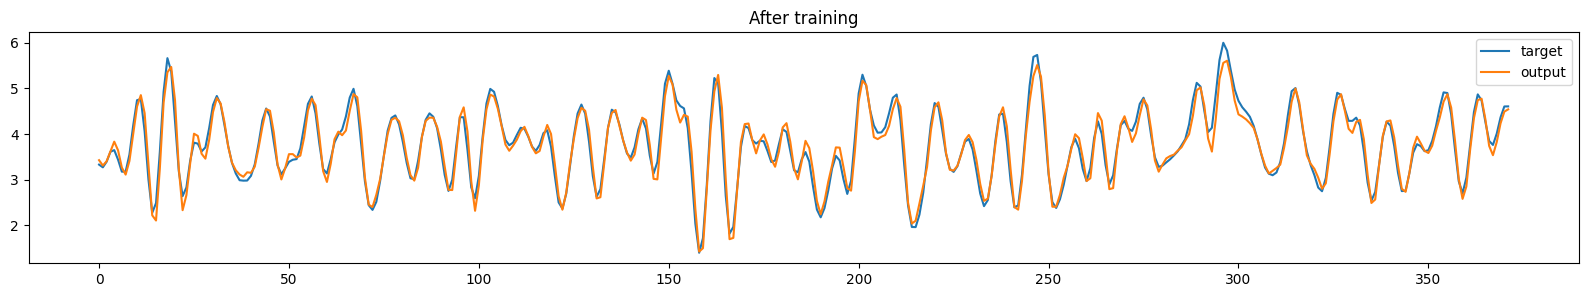

In [25]:
plt.figure(figsize = (20,3))
plt.plot(y_test[:,:], label="target")
plt.plot(y_pred, label="output")
# plt.xlim(-0.5, 20.5)
# plt.ylim(-1.1, 1.1)
plt.legend()
plt.title("After training")
plt.show()

In [26]:
y_test.shape, y_pred.shape

((372, 1), (372, 1))

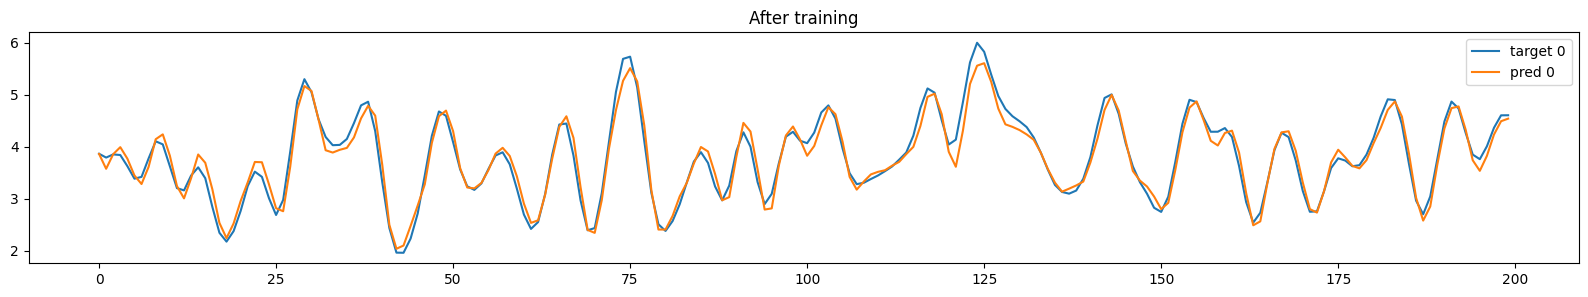

In [27]:
plt.figure(figsize = (20,3))
for i in range(1):
    plt.plot(y_test[-200:,i], label="target %i" % i)
    plt.plot(y_pred[-200:,i], label="pred %i" % i)
    # plt.xlim(-0.5, 20.5)
    # plt.ylim(-1.1, 1.1)
plt.legend()
plt.title("After training")
plt.show()

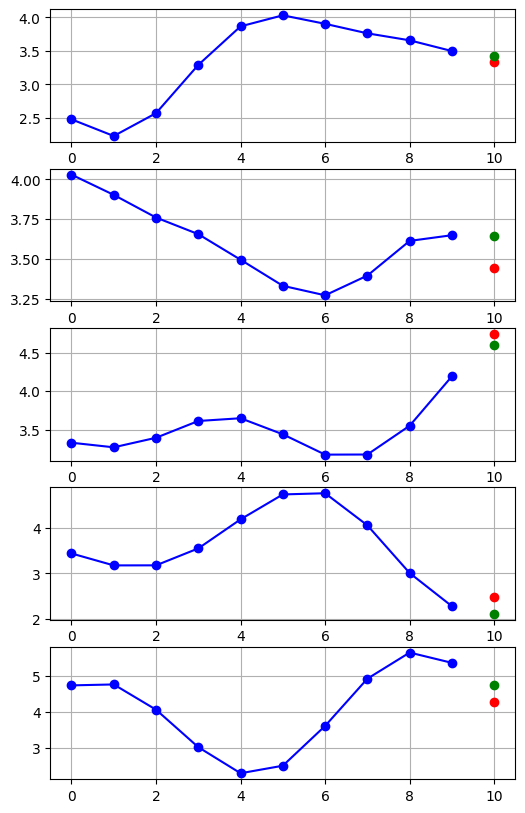

In [28]:
Nplt = 5
step = 5
plt.figure(figsize = (6, 2*Nplt))
for i in range(Nplt):
    plt.subplot(Nplt,1,i+1)
    plt.plot(np.arange(p), X_test[i*step,:], 'bo-', label="input seq")
    plt.plot(np.arange(q)+p, y_test[i*step], 'ro-', label="target")
    plt.plot(np.arange(q)+p, y_pred[i*step], 'go-', label="target")
    # plt.legend()
    plt.grid()
plt.show()

# 2. Sequence prediction (Seq-to-seq)

(1) 학습 데이터와 목표값 설정

In [29]:
s

array([3.33396966, 3.57086369, 3.9772853 , ..., 4.36587407, 4.60522567,
       4.60683985])

In [30]:
S.round(2)

array([[3.33, 3.57, 3.98, ..., 4.04, 4.41, 4.52],
       [3.57, 3.98, 4.39, ..., 4.41, 4.52, 4.29],
       [3.98, 4.39, 4.52, ..., 4.52, 4.29, 3.89],
       ...,
       [2.7 , 3.05, 3.76, ..., 3.76, 4.01, 4.37],
       [3.05, 3.76, 4.49, ..., 4.01, 4.37, 4.61],
       [3.76, 4.49, 4.87, ..., 4.37, 4.61, 4.61]])

In [31]:
X = S[:,:p][:, :, np.newaxis]
y = S[:,q:(p+q)]

test_size = 0.25
N_samples = X.shape[0]
N_timesteps = p

N_train = int(N_samples*(1-test_size))
N_test = int(N_samples*test_size)

y_test = y[-N_test:]
X_test = X[-N_test:,:,:]

y_train = y[:N_train]
X_train = X[:N_train,:,:]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1117, 10, 1), (1117, 10), (372, 10, 1), (372, 10))

(2) 학습 데이터와 목표 값 확인

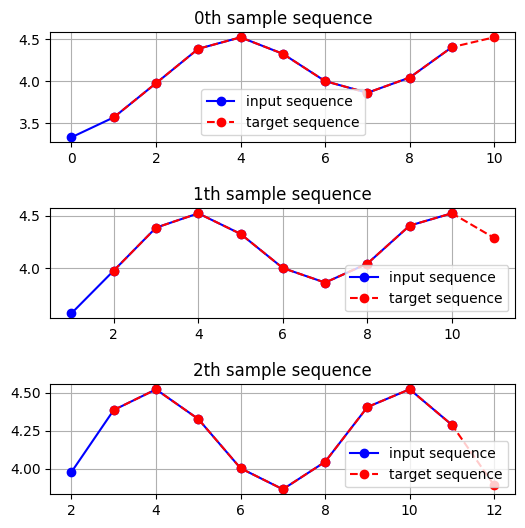

In [32]:
Nplt = 3
fig, ax_array = plt.subplots(Nplt, 1, figsize = (6,Nplt*2))
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2, hspace=0.6)
axes = ax_array.flatten()

for i in range(Nplt):
  # axes[i].subplot(Nplt,1,i+1)
  axes[i].plot(i+np.arange(N_timesteps), X_train[i].flatten(), 'bo-', label="input sequence")
  axes[i].plot(i+q+np.arange(N_timesteps), y_train[i].flatten(), 'ro--', label="target sequence")
  # axes[i].xlim(-0.5, 10.5)
  axes[i].legend()
  axes[i].set_title(str(i) + "th sample sequence")
  axes[i].grid()

plt.show()

In [33]:
N_timesteps, N_RNN_neurons

(10, 10)

In [34]:
from tensorflow.keras.layers import TimeDistributed

model2 = Sequential()
model2.add(SimpleRNN(N_RNN_neurons, return_sequences=True, input_shape=(N_timesteps, 1)))
model2.add(TimeDistributed(Dense(1, activation="linear")))
model.summary()

model2.compile(loss='mse', optimizer= tf.keras.optimizers.Adam(learning_rate=0.01) ) #'sgd')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133 (536.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

(5) 모델 훈련 (학습) 및 손실함수 확인

In [35]:
print('Training .. ', end='')
history2 = model2.fit(X_train, y_train, epochs=40)
print('done')

Training .. Epoch 1/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.5895 
Epoch 2/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4842
Epoch 3/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2970
Epoch 4/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2183
Epoch 5/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1804
Epoch 6/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1508
Epoch 7/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1321
Epoch 8/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1215
Epoch 9/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1122
Epoch 10/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1036
Epoch 11/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0955
Epoch 12/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0881
Epoch 13/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0813
Epoch 14/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0757
Epoch 15/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0701
Epoch 

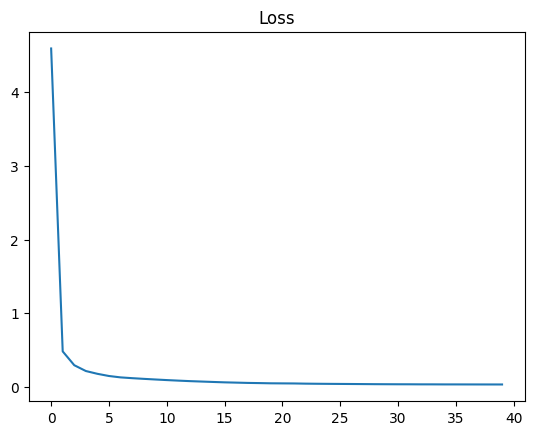

In [36]:
plt.plot(history2.history["loss"])
plt.title("Loss")
plt.show()

(6) 학습 후 출력 확인

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


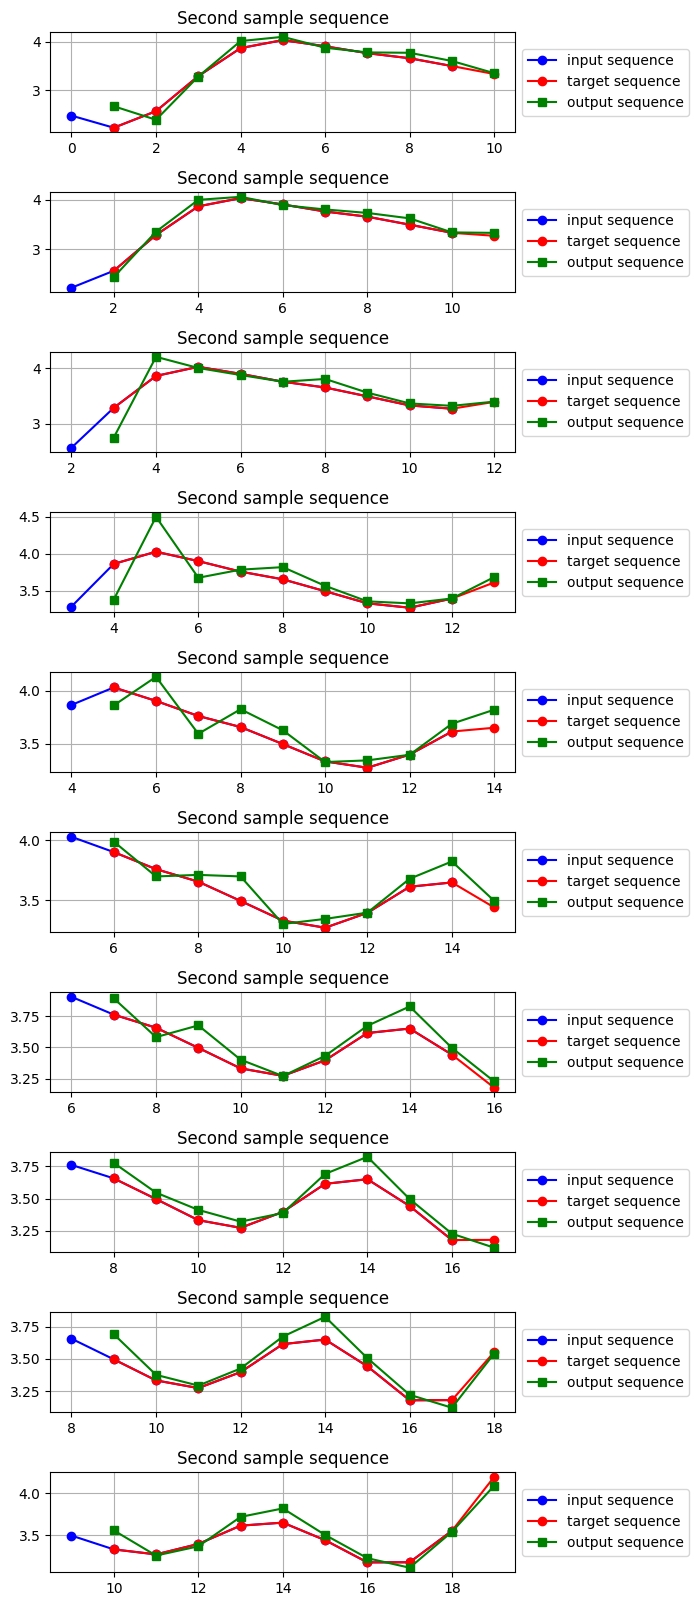

In [37]:
Nplt = 10
fig, ax_array = plt.subplots(Nplt, 1, figsize = (6,Nplt*2))
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2, hspace=0.6)
axes = ax_array.flatten()

for i in range(Nplt):
    axes[i].plot(i+np.arange(N_timesteps), X_test[i].flatten(), 'bo-', label="input sequence")
    axes[i].plot(i+q+np.arange(N_timesteps), y_test[i].flatten(), 'ro-', label="target sequence")
    axes[i].plot(i+q+np.arange(N_timesteps), model2.predict(X_test[i:i+1]).flatten(), 'gs-', label="output sequence")
    # axes[i].set_xlim(-3.5, 7.5)
    # axes[i].set_ylim(-1.1, 1.1)
    axes[i].legend(loc = 'center left', bbox_to_anchor = (1., 0.5))
    axes[i].set_title("Second sample sequence")
    axes[i].grid()

plt.show()